In [3]:
# Load in packages
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import itertools
from scipy.stats import ks_2samp
import random
import ast

## Loading in and cleaning data from matrix screening paper

In [ ]:
# PPI correlations from matrix screening data 
# Loading in data and extracting PPI pairs with sumIS > 7.1

# Read in supplemental table

sheet = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/matrix_screen_S2.csv")

# Drop unnecccesary columns 

col_to_keep = ['Protein A', 'Protein B', 'sumIS']

clean_sheet = sheet[col_to_keep]

# Filter for sumIS value based on recommended threshold from paper

filtered = clean_sheet[clean_sheet['sumIS'] >=7.1]

# Remane columns

filtered.columns = ['Bait', 'Prey', 'sumIS']

In [ ]:
# function to isolate RBP names, clean the dataframe, and write a csv with the correct pairs

def get_csv(cell_line): 

    # Want to filter table for RBPs that are in the glossary
    gloss = pd.read_csv(f'/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/{cell_line}_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv', sep='\t')

    # Get the list of protein names from glossary
    gloss_protein_names = gloss.columns.tolist()

    # Filter so it's only rows with Bait from glossary
    clean_bait = filtered[filtered["Bait"].isin(gloss_protein_names)]

    # Also need to filter the prey column

    # Filter so it's only rows with Bait from glossary
    clean_prey = clean_bait[clean_bait["Prey"].isin(gloss_protein_names)]

    clean_prey.to_csv(f"{cell_line}_matrix_PPI.csv", index = False)

## Getting PPI x SHAP correlations

In [4]:
def get_distributions(cell_line, number):
    
    ''' 
    calculates the Pearson and Spearman correlations for PPI pair SHAP values
    options for number of binding columns are 835 for K562
    or 631 for HepG2
    '''
        
    big_data_path = f"/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/{cell_line}_all-data.feather"
    
    big_data = pl.read_ipc(big_data_path)
        
    # get the binding columns
    subset_cols = big_data.columns[1:number]

    # unique based on them
    big_data_unique = big_data.unique(subset=subset_cols, keep="first")
        
    # Clean the PPI dataframe to get rid of duplicated PPIs

    ppi = pd.read_csv(f'/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/{cell_line}_matrix_PPI.csv')

    ppi["pair"] = ppi.apply(
        lambda row: tuple(sorted([row["Prey"], row["Bait"]])),
        axis=1
    )

    # Drop duplicates
    ppi_unique = ppi.drop_duplicates("pair")
        
    # Unique Binding Sites Correlations Dataframe

    positions = {1, 2, 3, 4, 5, 6}

    # create empty results dataframe with explicit types
    results = pl.DataFrame(
        {
            "Protein1": pl.Series(dtype=pl.Utf8),
            "Protein2": pl.Series(dtype=pl.Utf8),
            "Position": pl.Series(dtype=pl.Int64),
            "Pearson_Corr": pl.Series(dtype=pl.Float64),
            "Pearson_P": pl.Series(dtype=pl.Float64),
            "Spearman_Corr": pl.Series(dtype=pl.Float64),
            "Spearman_P": pl.Series(dtype=pl.Float64),
            "n": pl.Series(dtype=pl.Int64),
        }
    )

    for protein1, protein2 in ppi_unique["pair"]:
        for pos in positions:

            # dynamic column names
            bind1 = f"{protein1}_{pos}_binding"
            bind2 = f"{protein2}_{pos}_binding"
            shap1 = f"{protein1}_{pos}_shap"
            shap2 = f"{protein2}_{pos}_shap"

            # filter valid rows
            subset = big_data_unique.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))

            if subset.height in [0, 1]:
                # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
                continue

            # extract shap values as lists
            x = subset[shap1].to_list()
            y = subset[shap2].to_list()
            n_points = len(x)

            # calculate Pearson correlation
            pearson_corr, pearson_pval = pearsonr(x, y)

            # calculate Spearman correlation
            spearman_corr, spearman_pval = spearmanr(x, y)

            # append results
            results = results.vstack(
                pl.DataFrame(
                    {
                        "Protein1": [protein1],
                        "Protein2": [protein2],
                        "Position": [pos],
                        "Pearson_Corr": [pearson_corr],
                        "Pearson_P": [pearson_pval],
                        "Spearman_Corr": [spearman_corr],
                        "Spearman_P": [spearman_pval],
                        "n": [n_points],
                    }
                )
            )
            
    return results

In [5]:
k562 = get_distributions('K562', 835)

k562_final = k562.to_pandas()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
/tmp/ipykernel_619471/822950151.py:71: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_pval = pearsonr(x, y)
/tmp/ipykernel_619471/822950151.py:74: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_pval = spearmanr(x, y)


In [6]:
hepg2 = get_distributions('HepG2', 631)

hepg2_final = hepg2.to_pandas()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
/tmp/ipykernel_619471/822950151.py:71: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_pval = pearsonr(x, y)
/tmp/ipykernel_619471/822950151.py:74: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_pval = spearmanr(x, y)


## Plotting distributions of correlations for PPI pairs

13


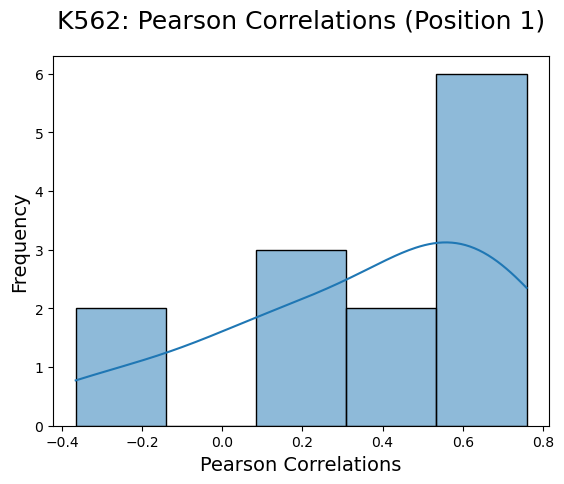

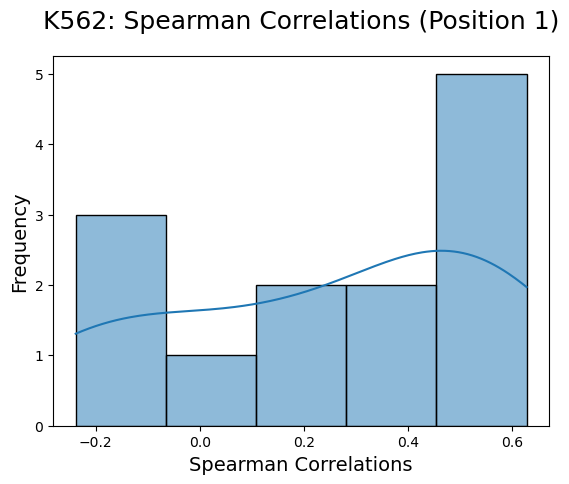

19


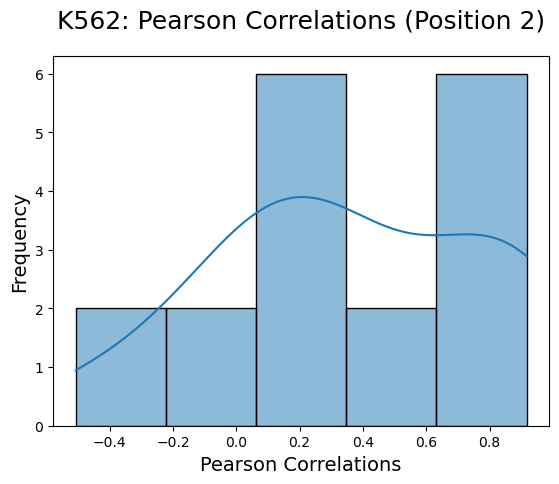

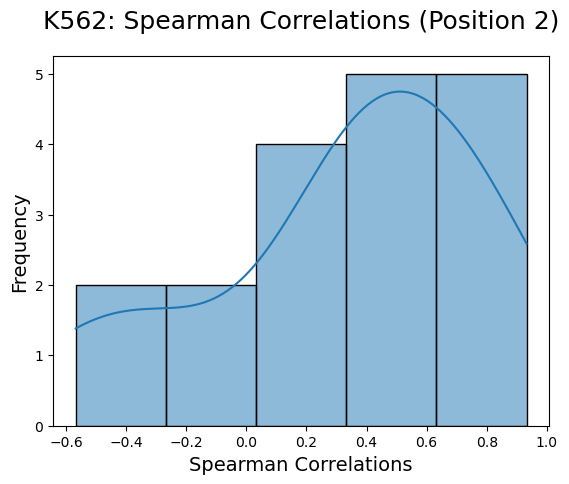

17


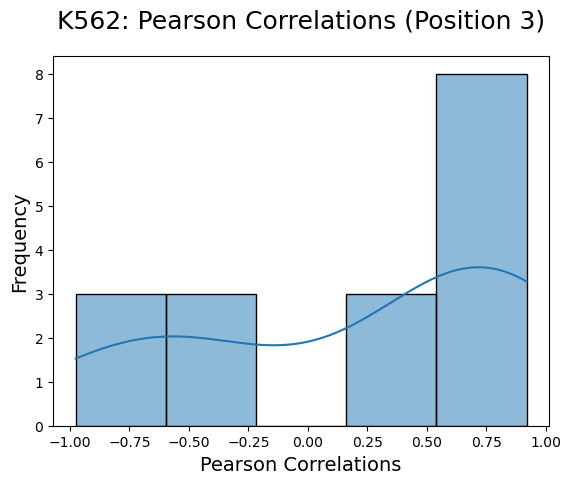

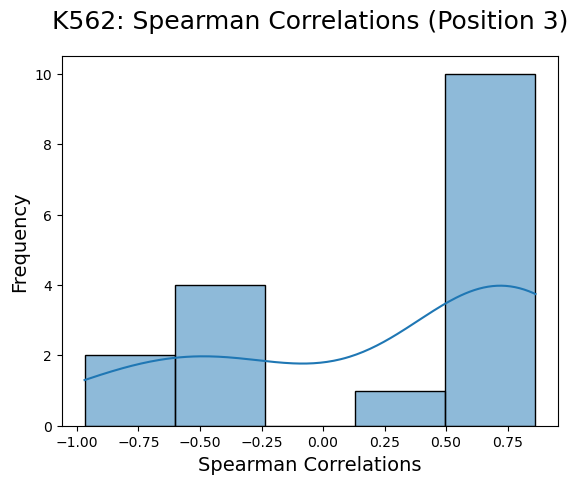

14


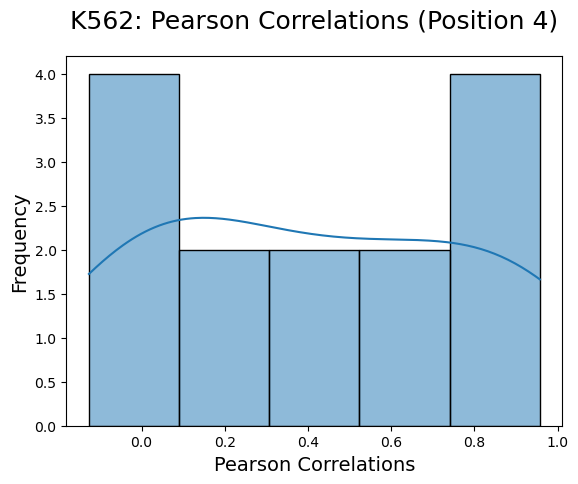

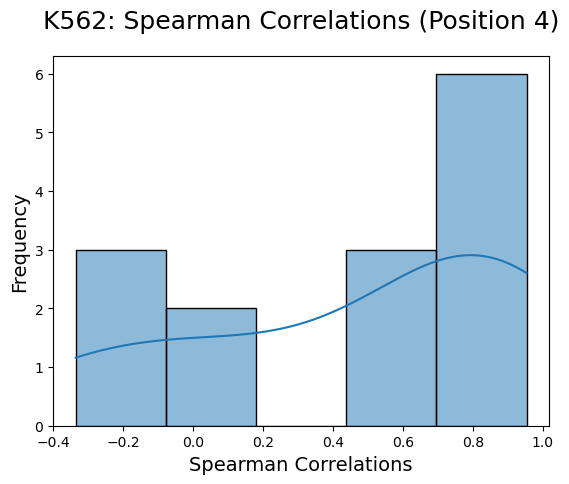

17


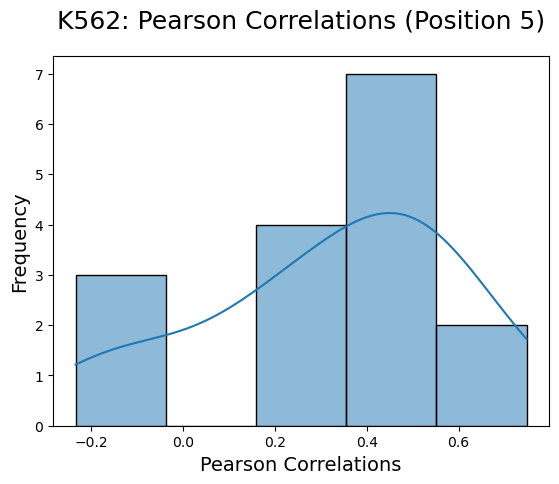

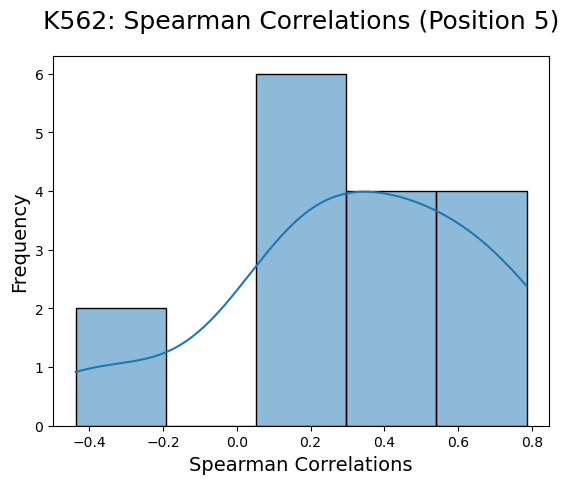

16


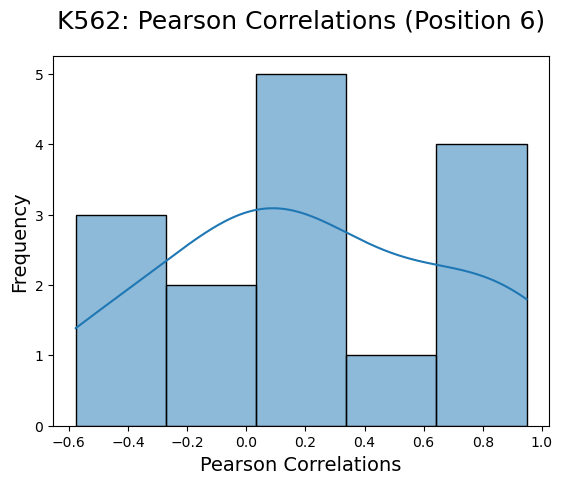

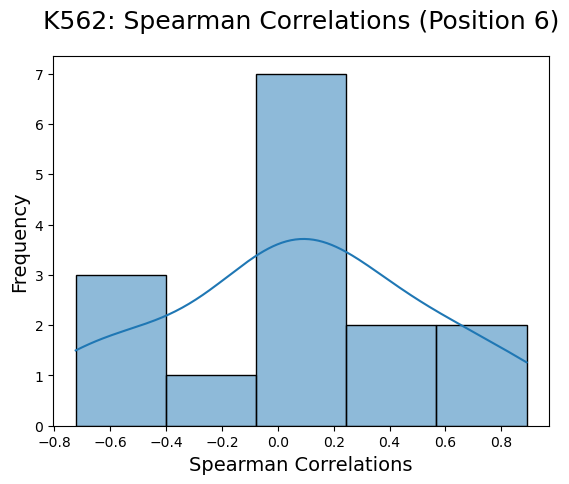

In [7]:
# K562 Distribution of Pearson and Spearman correlations per position with cutoff of 30 events 

positions = [1, 2, 3, 4, 5, 6]

for pos in positions:
    subset = k562_final[(k562_final["Position"] == pos) & (k562_final["n"] > 30)]
    print(len(subset))
    
    sns.histplot(subset["Pearson_Corr"], kde = True, bins = 5)
    plt.title(f"K562: Lang et al. PPI Pearson Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()
    
    sns.histplot(subset["Spearman_Corr"], kde = True, bins = 5)
    plt.title(f"K562: Lang et al. PPI Spearman Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()

96


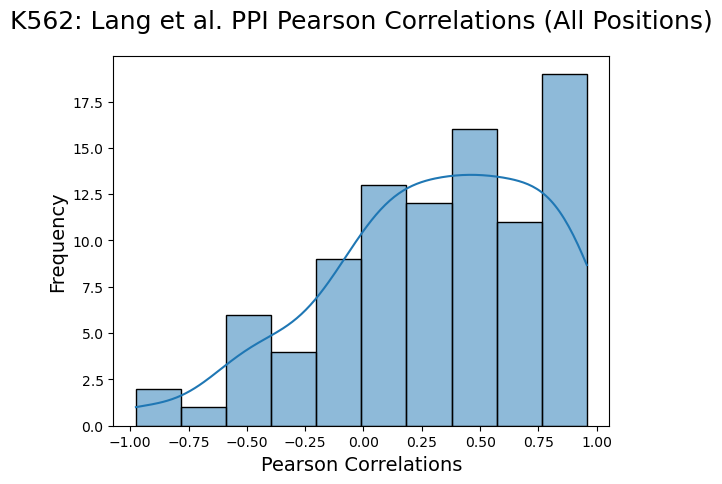

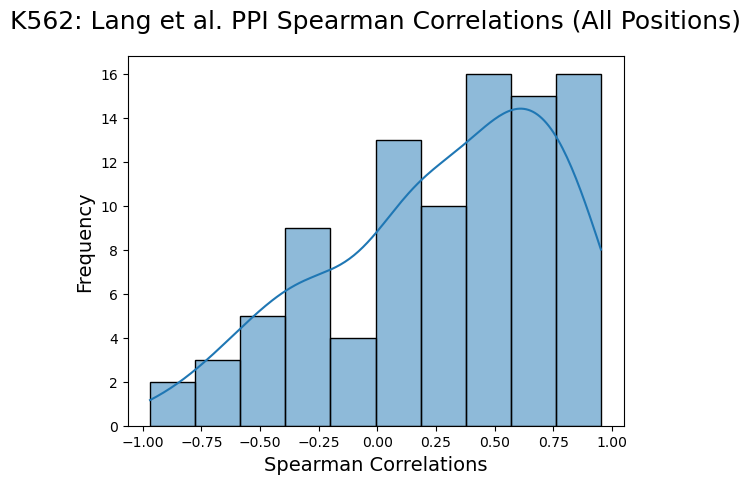

In [16]:
# All positons

subset = k562_final[(k562_final["n"] > 30)]
print(len(subset))

sns.histplot(data = subset, x = "Pearson_Corr", kde = True, bins = 10)
plt.title(f"K562: Lang et al. PPI Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = subset, x = "Spearman_Corr", kde = True, bins = 10)
plt.title(f"K562: Lang et al. PPI Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

7


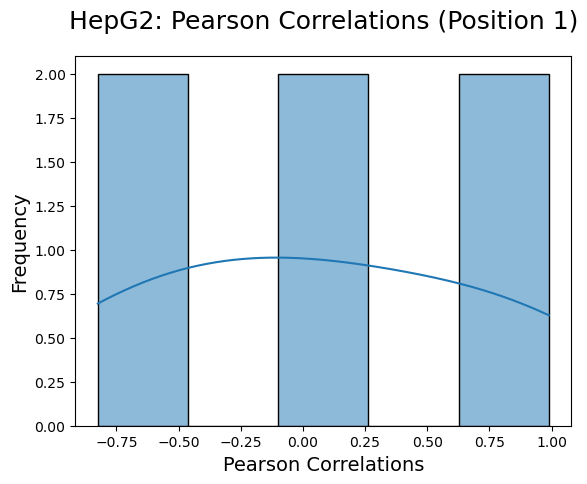

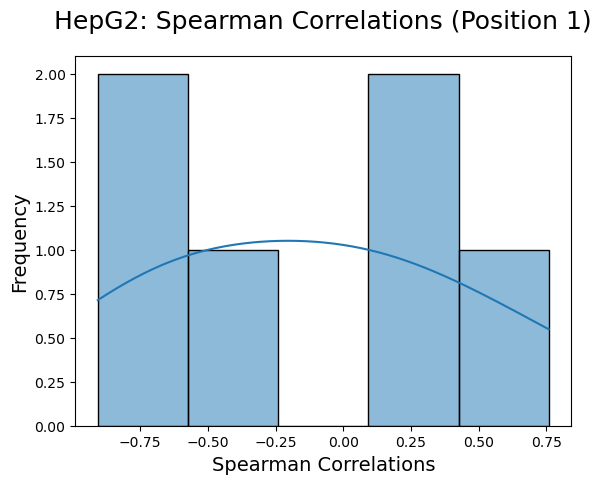

10


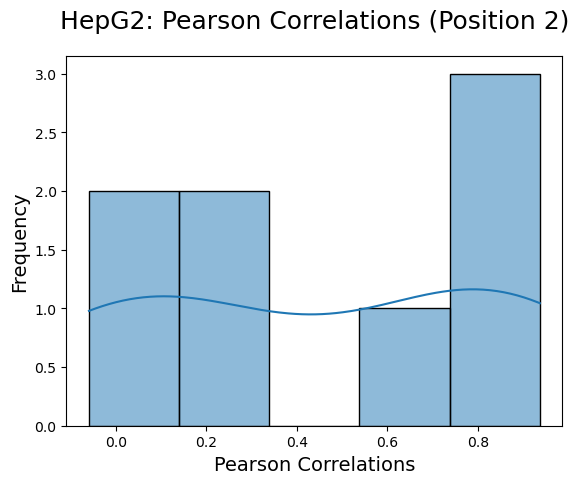

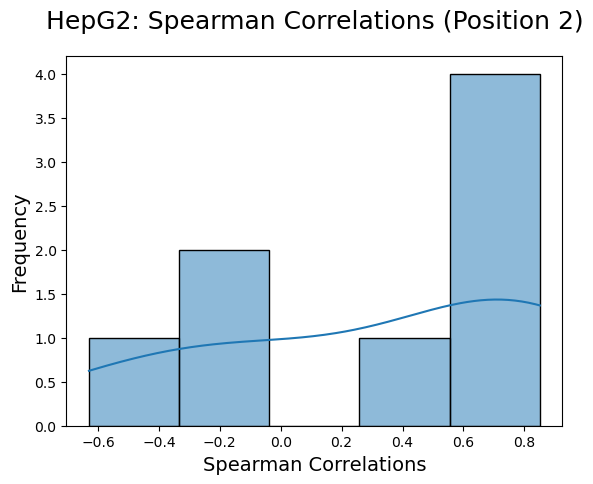

10


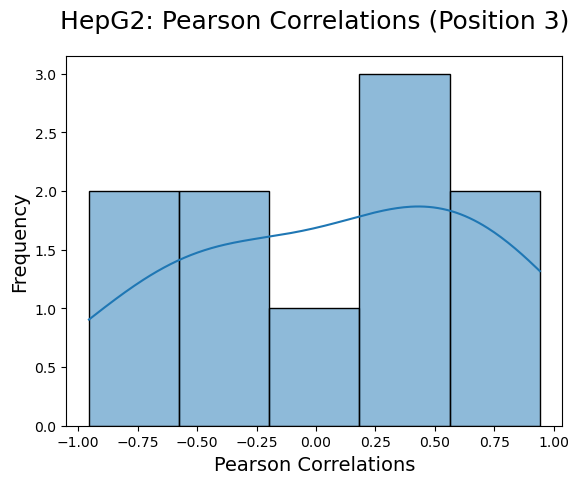

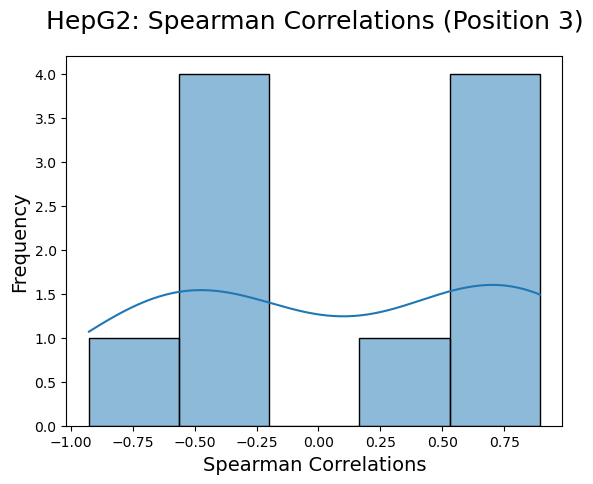

12


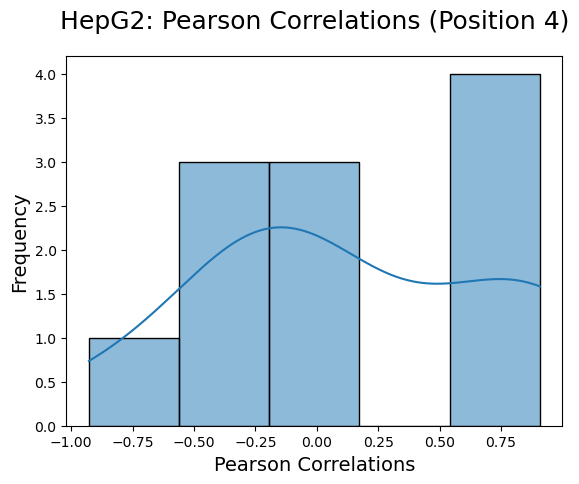

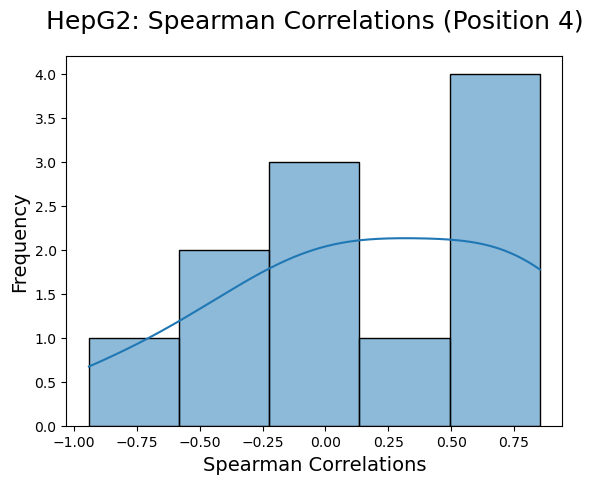

9


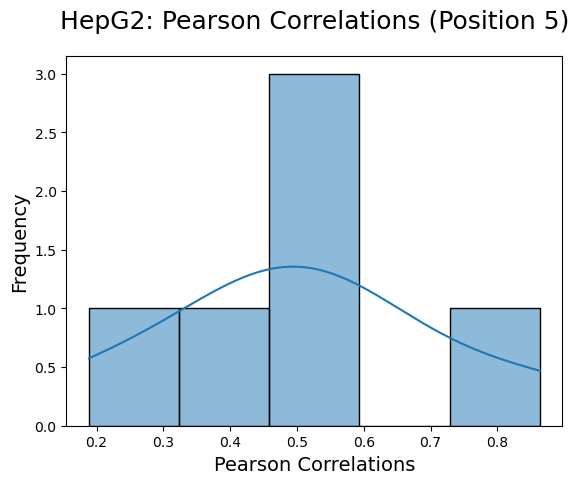

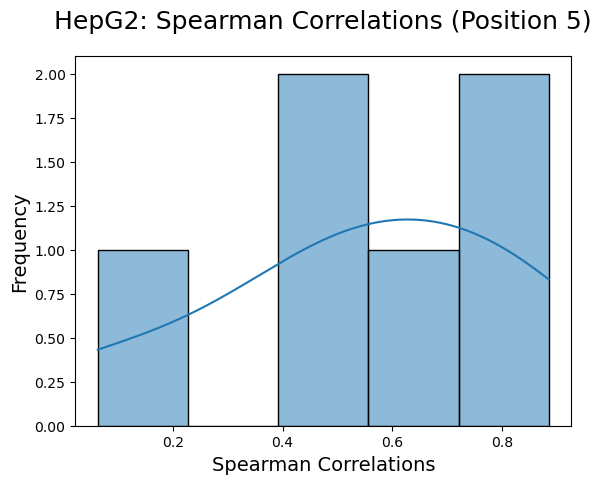

11


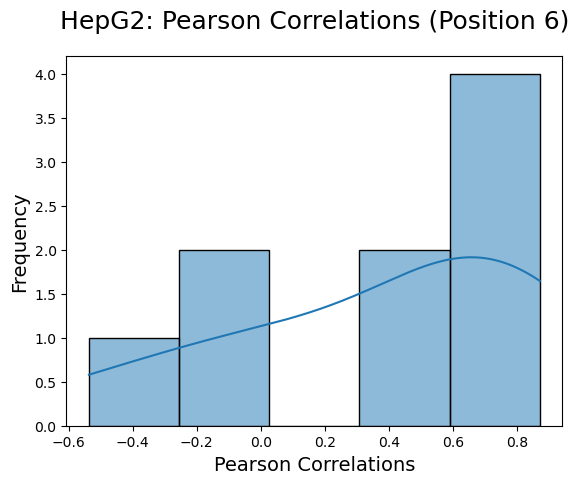

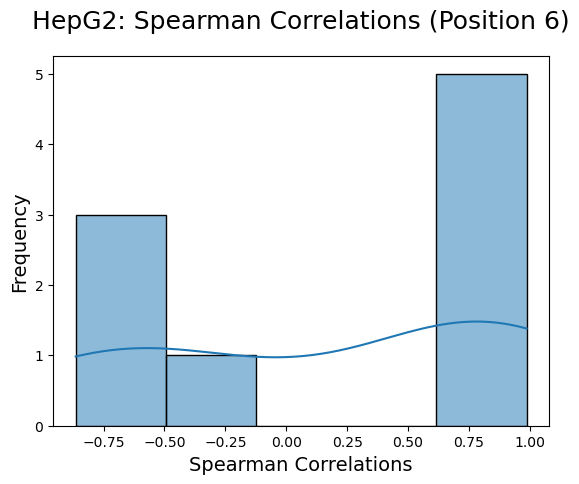

In [10]:
# HepG2 Distribution of Pearson and Spearman correlations per position with cutoff of 30 events 

positions = [1, 2, 3, 4, 5, 6]

for pos in positions:
    subset = hepg2_final[(hepg2_final["Position"] == pos) & (hepg2_final["n"] > 30)]
    print(len(subset))
    
    sns.histplot(subset["Pearson_Corr"], kde = True, bins = 5)
    plt.title(f"HepG2: Lang et al. PPI Pearson Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()
    
    sns.histplot(subset["Spearman_Corr"], kde = True, bins = 5)
    plt.title(f"HepG2: Lang et al. PPI Spearman Correlations (Position {pos})", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()

59


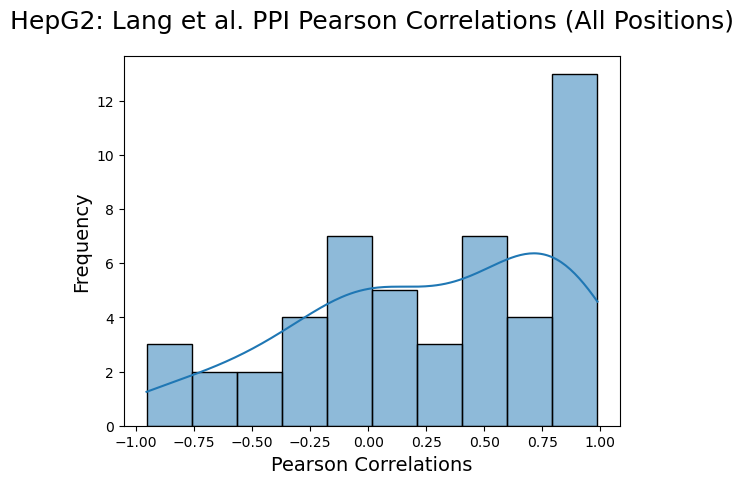

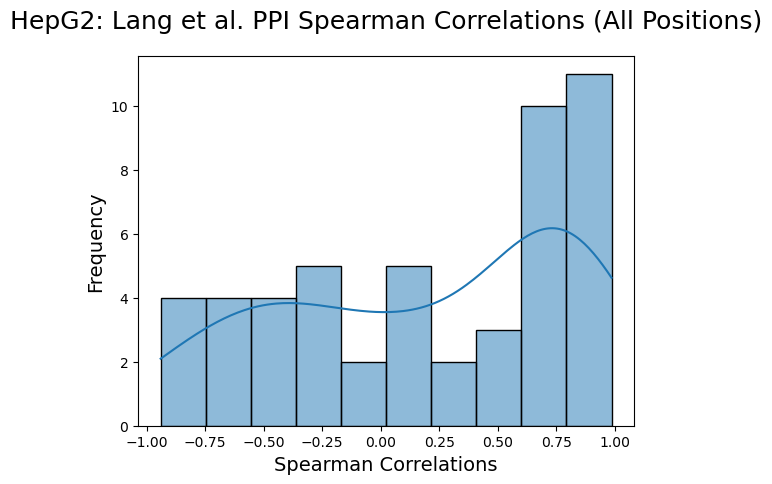

In [17]:
# All positons

subset = hepg2_final[(hepg2_final["n"] > 30)]
print(len(subset))

sns.histplot(data = subset, x = "Pearson_Corr", kde = True, bins = 10)
plt.title(f"HepG2: Lang et al. PPI Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Pearson Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

sns.histplot(data = subset, x = "Spearman_Corr", kde = True, bins = 10)
plt.title(f"HepG2: Lang et al. PPI Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
plt.xlabel("Spearman Correlations", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.show()

## Creating Null Distribution
### Select any 2 RBPs and correlate their SHAP values

In [1]:
def get_random_dists(cell_line, number, pair_numbers):

    '''
    cell_line = HepG2 or K562
    number = 835 for K562 or 631 for HepG2
    pair_numbers = 55 for K562 or 39 for HepG2

    
    Returns a dataframe of random RBP-RBP pairs with >30 samples and their Pearson and Spearman Correlations
    '''

    big_data_path = f"/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/{cell_line}_all-data.feather"
    
    big_data = pl.read_ipc(big_data_path)
    
    # get the binding columns
    subset_cols = big_data.columns[1:631]
    
    # unique binding pattern df
    unique_bp = big_data.unique(subset=subset_cols, keep="first")
    
    # Extracting protein names
    
    cols = big_data.columns  
    
    # filter for columns ending with "_1_binding"
    binding_cols = [c for c in cols if c.endswith("_1_binding")]
    
    # extract protein names by removing the suffix
    proteins = [c.replace("_1_binding", "") for c in binding_cols]
    
    # Selecting random protein pairs

    # make all possible unordered pairs of proteins
    all_pairs = list(itertools.combinations(proteins, 2))
    
    # shuffle to randomize
    random.shuffle(all_pairs)
    
    # Try select number of pairs
    selected_pairs = all_pairs[:pair_numbers]

    # Put the pairs into a dataframe with protein1, protein2, and pair

    rbp_pairs = pd.DataFrame({
        "protein1": [p1 for p1, p2 in selected_pairs],
        "protein2": [p2 for p1, p2 in selected_pairs],
        "pair": [(p1, p2) for p1, p2 in selected_pairs],  # <-- tuple, not string
    })
        
    # Unique Binding Sites Correlations Dataframe
    
    positions = [1, 2, 3, 4, 5, 6]
    
    # create empty results dataframe with explicit types
    corr_results = pl.DataFrame(
        {
            "Protein1": pl.Series(dtype=pl.Utf8),
            "Protein2": pl.Series(dtype=pl.Utf8),
            "Position": pl.Series(dtype=pl.Int64),
            "Pearson_Corr": pl.Series(dtype=pl.Float64),
            "Pearson_P": pl.Series(dtype=pl.Float64),
            "Spearman_Corr": pl.Series(dtype=pl.Float64),
            "Spearman_P": pl.Series(dtype=pl.Float64),
            "n": pl.Series(dtype=pl.Int64),
        }
    )
    
    
    for protein1, protein2 in rbp_pairs["pair"]:
        for pos in positions:
            # dynamic column names
            bind1 = f"{protein1}_{pos}_binding"
            bind2 = f"{protein2}_{pos}_binding"
            shap1 = f"{protein1}_{pos}_shap"
            shap2 = f"{protein2}_{pos}_shap"
    
            # filter valid rows
            subset = unique_bp.filter((pl.col(bind1) == 1) & (pl.col(bind2) == 1))
            
            if subset.height in [0, 1]:
                # print(f"No valid rows for pair {protein1}-{protein2}, skipping.")
                continue
    
            # extract shap values as lists
            x = subset[shap1].to_list()
            y = subset[shap2].to_list()
            n_points = len(x)
    
            # calculate Pearson correlation
            pearson_corr, pearson_pval = pearsonr(x, y)
    
            # calculate Spearman correlation
            spearman_corr, spearman_pval = spearmanr(x, y)
        
            # append results
            corr_results = corr_results.vstack(
                pl.DataFrame(
                    {
                        "Protein1": [protein1],
                        "Protein2": [protein2],
                        "Position": [pos],
                        "Pearson_Corr": [pearson_corr],
                        "Pearson_P": [pearson_pval],
                        "Spearman_Corr": [spearman_corr],
                        "Spearman_P": [spearman_pval],
                        "n": [n_points],
                    }
                )
            )
    
    corr_results = corr_results.to_pandas()
    
    corr_results_final = corr_results[(corr_results["n"] > 30)]

    return corr_results_final

In [7]:
corr_results_final = get_random_dists("HepG2", 631, 39)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
/tmp/ipykernel_689097/3985622795.py:91: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_pval = pearsonr(x, y)
/tmp/ipykernel_689097/3985622795.py:94: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_pval = spearmanr(x, y)


In [20]:
def each_positon_plot(df, cell_line):
    '''
    df = a dataframe with protein pairs and correlation values
    cell_line = K562 or HepG2
    '''

    positions = [1, 2, 3, 4, 5, 6]

    for pos in positions:
        
        # Get the coors from the right position
        subset = df[(df["Position"] == pos)]
        print(len(subset))
        
        # Plot Pearson and Spearman Correlation Distributions
        plot1 = sns.histplot(subset["Pearson_Corr"], kde = True, bins = 5, color = "red")
        plt.title(f"{cell_line}: Lang et al. Random Pair Pearson Correlations (Position {pos})", fontsize = 18, pad = 20)
        plt.xlabel("Pearson Correlations", fontsize = 14, labelpad = 10)
        plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
        plt.show()
        
        plot2 = sns.histplot(subset["Spearman_Corr"], kde = True, bins = 5, color = "red")
        plt.title(f"{cell_line}: Lang et al. Random Pair Spearman Correlations (Position {pos})", fontsize = 18, pad = 20)
        plt.xlabel("Spearman Correlations", fontsize = 14, labelpad = 10)
        plt.ylabel("Frequency", fontsize = 14, labelpad = 10)
        plt.show()
        print(f"Plot for position {pos}")

    return plot1, plot2

11


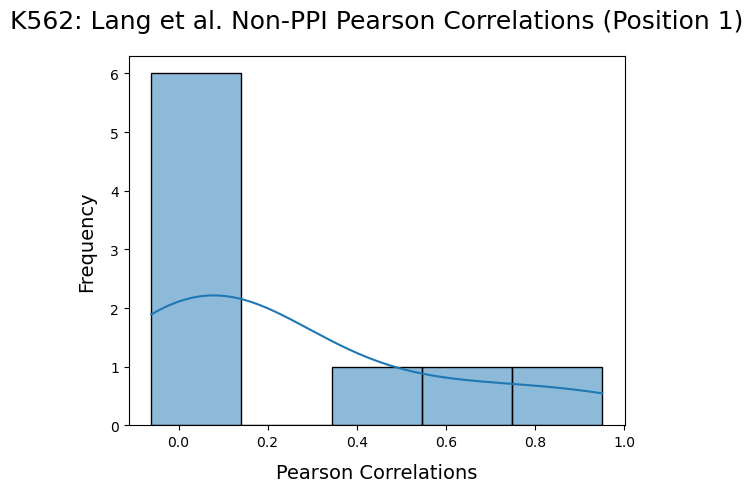

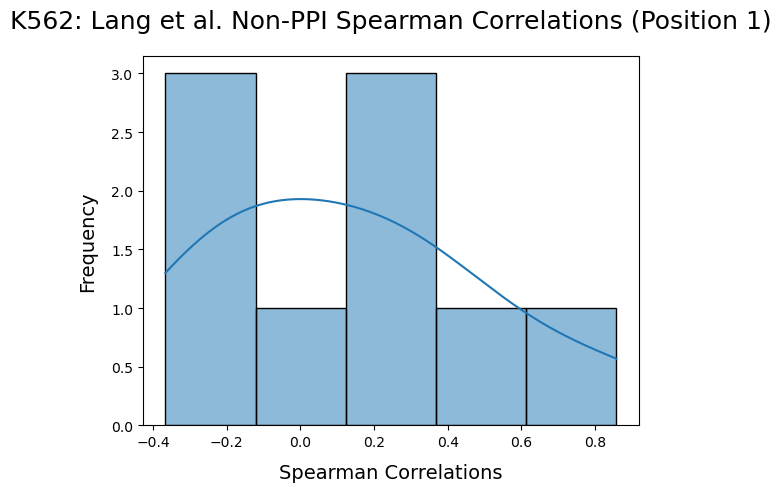

Plot for position 1
14


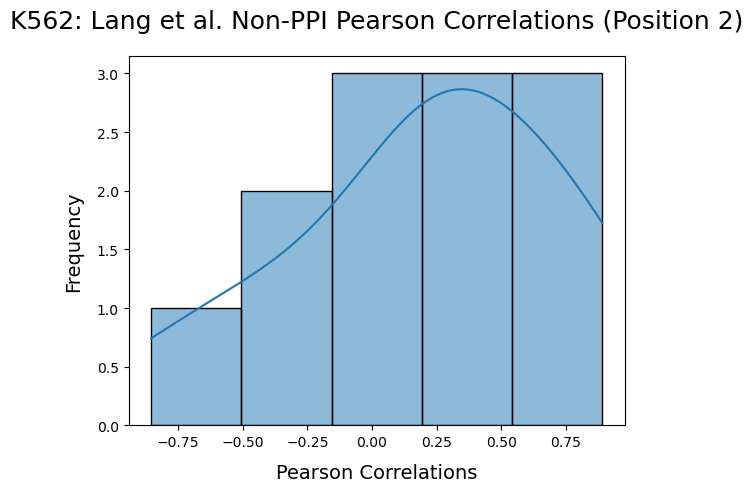

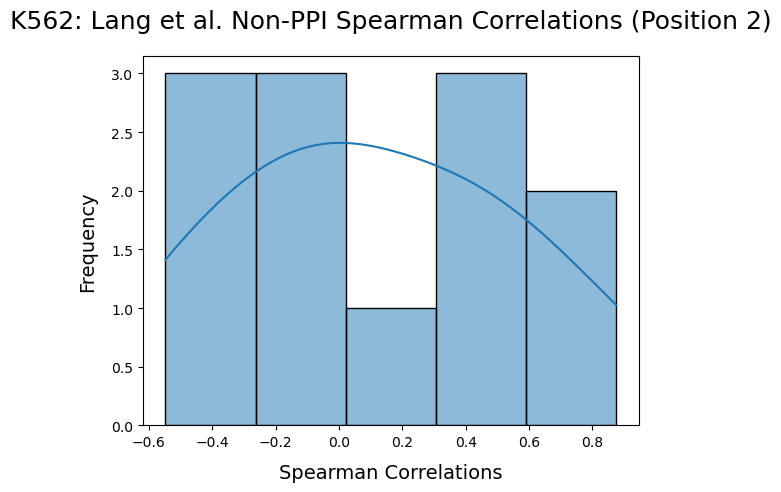

Plot for position 2
13


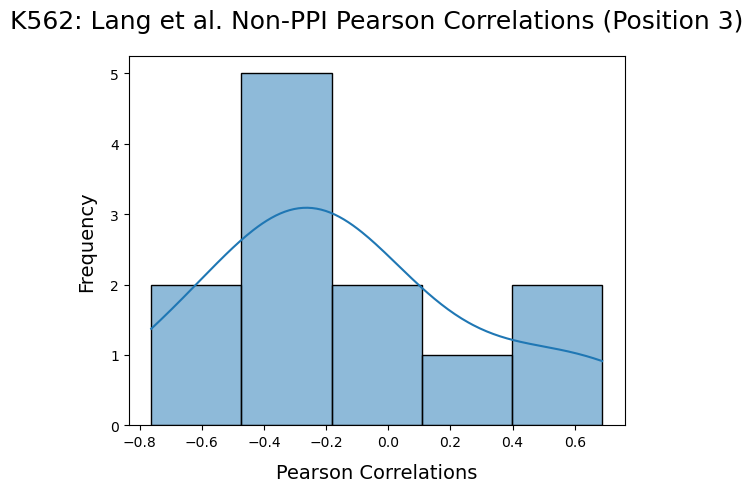

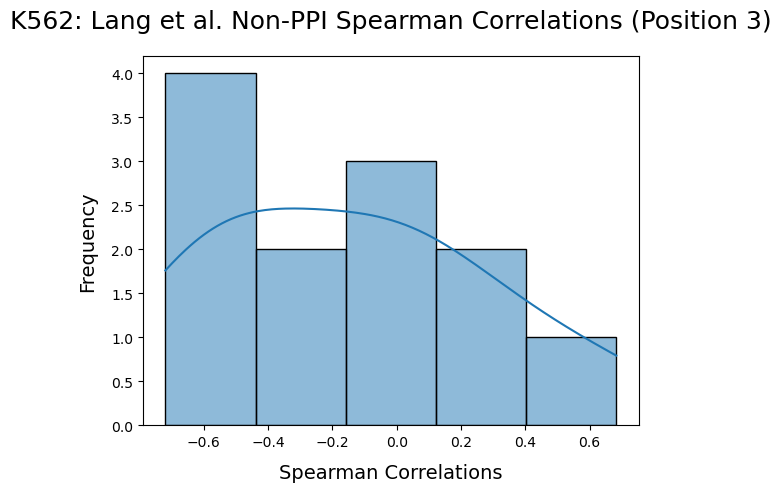

Plot for position 3
9


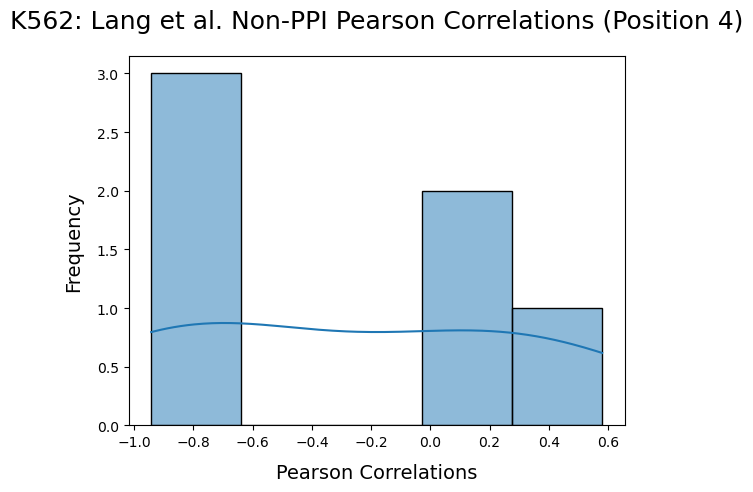

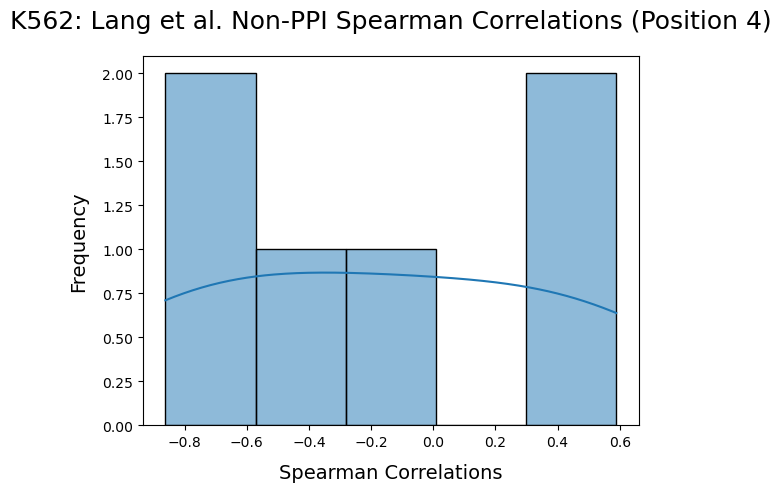

Plot for position 4
11


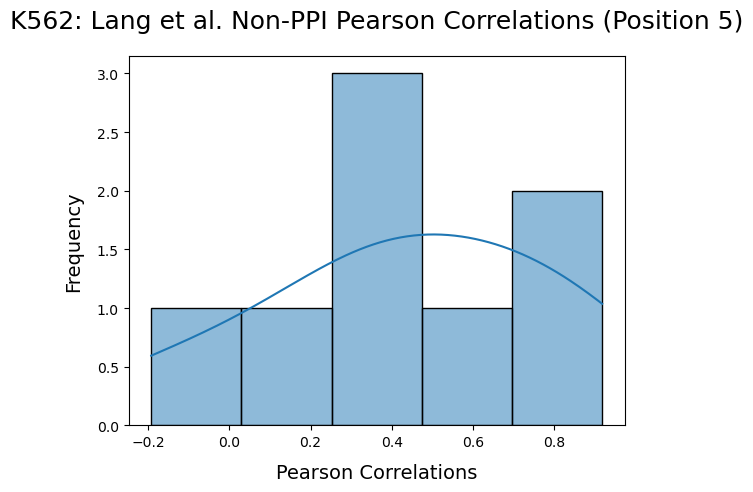

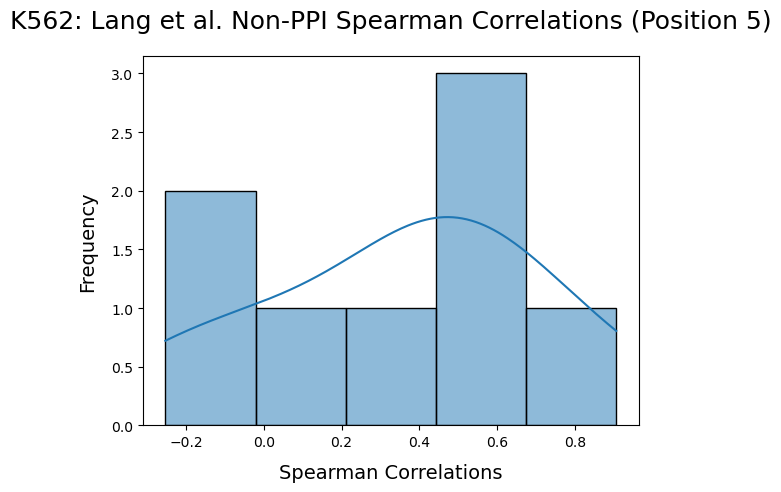

Plot for position 5
5


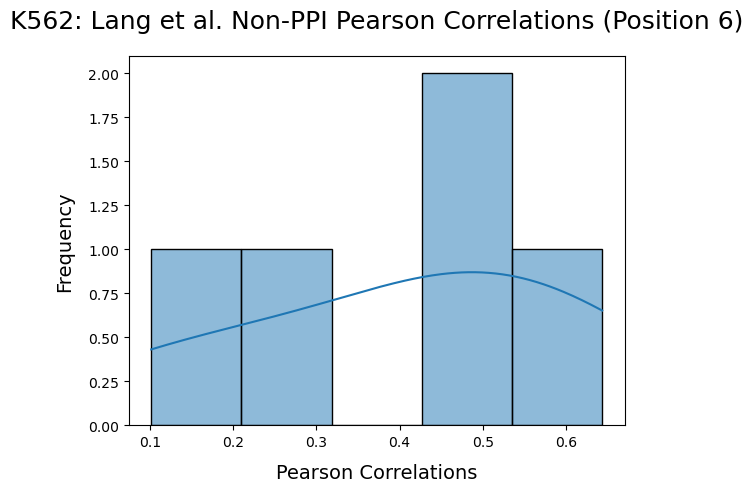

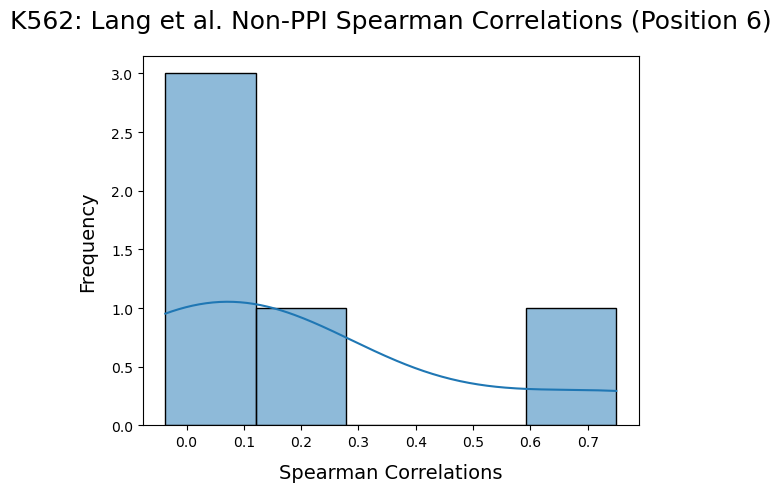

Plot for position 6


(<Axes: title={'center': 'K562: Lang et al. Non-PPI Pearson Correlations (Position 6)'}, xlabel='Pearson Correlations', ylabel='Frequency'>,
 <Axes: title={'center': 'K562: Lang et al. Non-PPI Spearman Correlations (Position 6)'}, xlabel='Spearman Correlations', ylabel='Frequency'>)

In [32]:
each_positon_plot(corr_results_final, "K562")

In [8]:
def all_positions_plot(df, cell_line):

    '''
    df = a dataframe with protein pairs and correlation values
    cell_line = K562 or HepG2
    '''
    
    plot1 = sns.histplot(data = df, x = "Pearson_Corr", kde = True, bins = 10, color = "red")
    plt.title(f"{cell_line}: Lang et al. Random Pair Pearson Correlations (All Positions)", fontsize = 18, pad = 20)
    plt.xlabel("Pearson Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()
    
    plot2 = sns.histplot(data = df, x = "Spearman_Corr", kde = True, bins = 10, color = "red")
    plt.title(f"{cell_line}: Lang et al. Random Pair Spearman Correlations (All Positions)", fontsize = 18, pad = 20)
    plt.xlabel("Spearman Correlations", fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    plt.show()

    return plot1, plot2

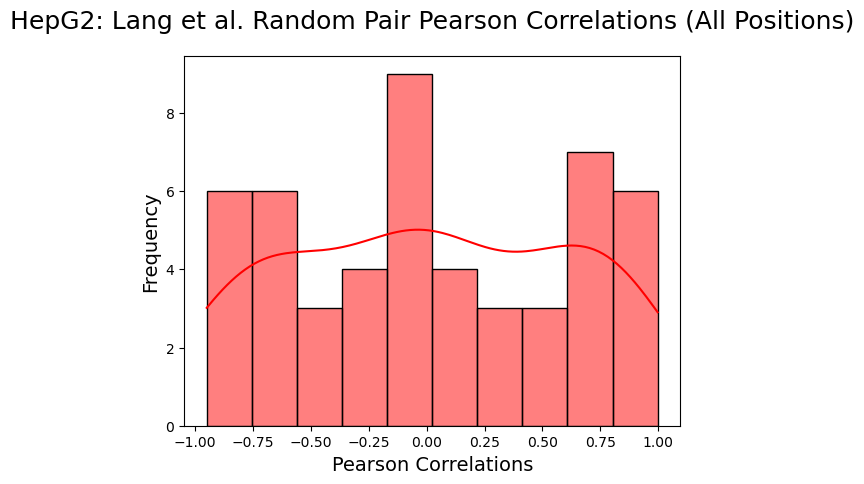

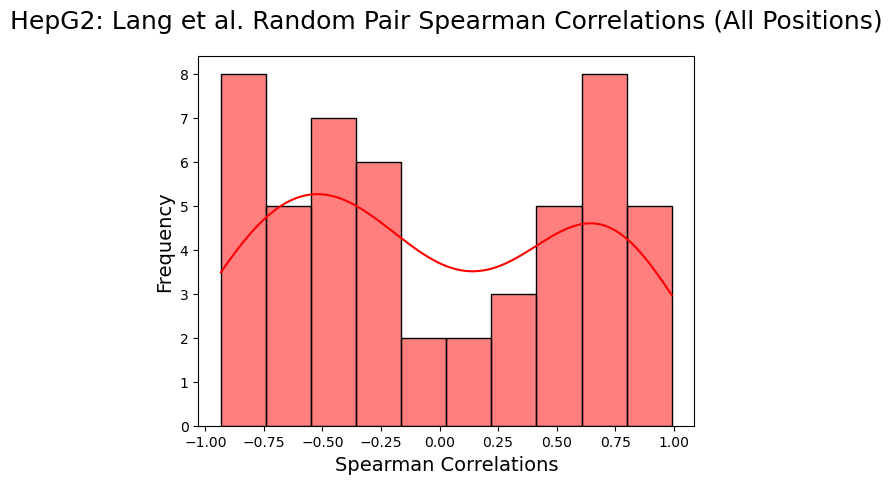

(<Axes: title={'center': 'HepG2: Lang et al. Random Pair Pearson Correlations (All Positions)'}, xlabel='Pearson Correlations', ylabel='Frequency'>,
 <Axes: title={'center': 'HepG2: Lang et al. Random Pair Spearman Correlations (All Positions)'}, xlabel='Spearman Correlations', ylabel='Frequency'>)

In [9]:
all_positions_plot(corr_results_final, "HepG2")

## KS Tests

In [35]:
def ks_test(df, cell_line):
    '''
    df = a dataframe with protein pairs and correlation values
    cell_line = K562 or HepG2
    this function automatically loads in the actually ppi corrs based on the cell line
    '''

    ppi_final = pd.read_csv(f'/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/2_rbp_pair_shap_correlations/data/final_{cell_line}_matrix_ppis.csv')
    non_ppi_final = df

    print(ppi_final.shape)
    print(non_ppi_final.shape)

    # KS Tests

    # List to store results
    results = []
    
    positions = [1, 2, 3, 4, 5, 6]
    
    for pos in positions:
        # Subset for position
        subset_p = ppi_final[(ppi_final["Position"] == pos)]
        
        # Subset other df for position
        subset_np = non_ppi_final[(non_ppi_final["Position"] == pos)]
    
        pearson_p = subset_p["Pearson_Corr"].dropna().to_numpy()
        pearson_np = subset_np["Pearson_Corr"].dropna().to_numpy()

        ks_stat, p_val = ks_2samp(pearson_p, pearson_np)
    
        # Append results
        results.append({
            "position": pos,
            "ks_test_stat": ks_stat,
            "p_val": p_val
        })
        
    # Convert results to DataFrame
    ks_results_df = pd.DataFrame(results)
    
    print(f"KS Test Results {cell_line}")
    print(ks_results_df)

    # For all positions

    results_all = []

    subset_p_all = ppi_final
    
        
    # Isolate pearson values as numpy array
    pearson_p_all = subset_p_all["Pearson_Corr"].dropna().to_numpy()
        
    subset_np_all = non_ppi_final
        
    # Isolate pearson values as numpy array
    pearson_np_all = subset_np_all["Pearson_Corr"].dropna().to_numpy()
    
    ks_stat, p_val = ks_2samp(pearson_p_all, pearson_np_all)
    
    # Append results
    results_all.append({
        "ks_test_stat": ks_stat,
        "p_val": p_val
    })
        
    # Convert results to DataFrame
    ks_results_all_pos_df = pd.DataFrame(results_all)
    
    print(f"KS Test Results {cell_line} all positions")
    print(ks_results_all_pos_df)

In [36]:
ks_test(corr_results_final, "K562")

(96, 8)
(63, 8)
KS Test Results K562
   position  ks_test_stat     p_val
0         1      0.358974  0.400306
1         2      0.194444  0.918286
2         3      0.480392  0.053624
3         4      0.500000  0.187822
4         5      0.312500  0.655583
5         6      0.533333  0.205366
KS Test Results K562 all positions
   ks_test_stat     p_val
0      0.189826  0.154534
